In [84]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from corus import load_lenta
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import TruncatedSVD, NMF, LatentDirichletAllocation
from bertopic import BERTopic
from fastopic import FASTopic


In [85]:
import nltk
nltk.download('stopwords', quiet=True)
from nltk.corpus import stopwords
russian_stop = stopwords.words('russian')

In [86]:
# 1. Load Lenta corpus (first 2000 articles for speed)
LENTA_PATH = '/Users/juliak/PycharmProjects/MSP/TM/lenta-ru-news.csv.gz'
def load_docs(path: str, limit: int = 2000):
    docs = []
    for i, record in enumerate(load_lenta(path)):
        if i >= limit:
            break
        docs.append(record.text)
    return docs

In [87]:
# 2. Vectorizers
vectorizer_tfidf = TfidfVectorizer(max_df=0.9, min_df=10, stop_words=russian_stop)
vectorizer_count = CountVectorizer(max_df=0.9, min_df=10, stop_words=russian_stop)

In [96]:
# 3. Train models
def train_lsa(docs, n_topics=10):
    X = vectorizer_tfidf.fit_transform(docs)
    model = TruncatedSVD(n_components=n_topics, random_state=42)
    model.fit(X)
    return model

def train_lda(docs, n_topics=10):
    X = vectorizer_count.fit_transform(docs)
    model = LatentDirichletAllocation(n_components=n_topics, random_state=42)
    model.fit(X)
    return model

def train_nmf(docs, n_topics=10):
    X = vectorizer_tfidf.fit_transform(docs)
    model = NMF(n_components=n_topics, random_state=42)
    model.fit(X)
    return model

def train_bertopic(docs, n_topics=10):
    model = BERTopic(nr_topics=n_topics, language='russian')
    model.fit(docs)
    return model

def train_fastopic(docs, n_topics=10):
    fake_preprocess = lambda docs: docs  # заглушка, если FASTopic не будет требовать реальный препроцесс
    model = FASTopic(num_topics=5, preprocess=fake_preprocess, low_memory=True)
    # model = FASTopic(num_topics=n_topics)
    model.fit(docs)
    return model

In [89]:
# 4. Plot top words helper
def plot_top_words(model, feature_names, n_top_words=8, title=''):
    n_topics = model.n_components
    fig, axes = plt.subplots(1, n_topics, figsize=(2*n_topics, 6), sharex=False)
    for idx, comp in enumerate(model.components_):
        top_idx = np.argsort(comp)[-n_top_words:]
        words = [feature_names[i] for i in top_idx]
        weights = comp[top_idx]
        ax = axes[idx]
        ax.barh(words, weights)
        ax.set_title(f"Topic {idx}")
        ax.invert_yaxis()
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()

In [90]:
# 5. Run and visualize
if __name__ == '__main__':
    docs = load_docs(LENTA_PATH, limit=2000)



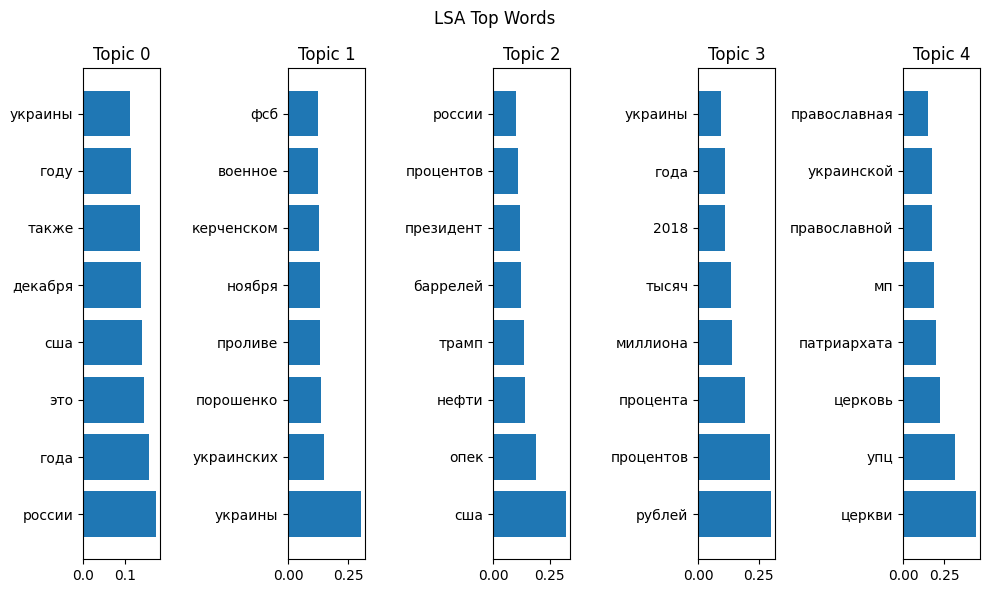

In [91]:
    # LSA
lsa_model = train_lsa(docs, n_topics=5)
plot_top_words(lsa_model, vectorizer_tfidf.get_feature_names_out(), title='LSA Top Words')


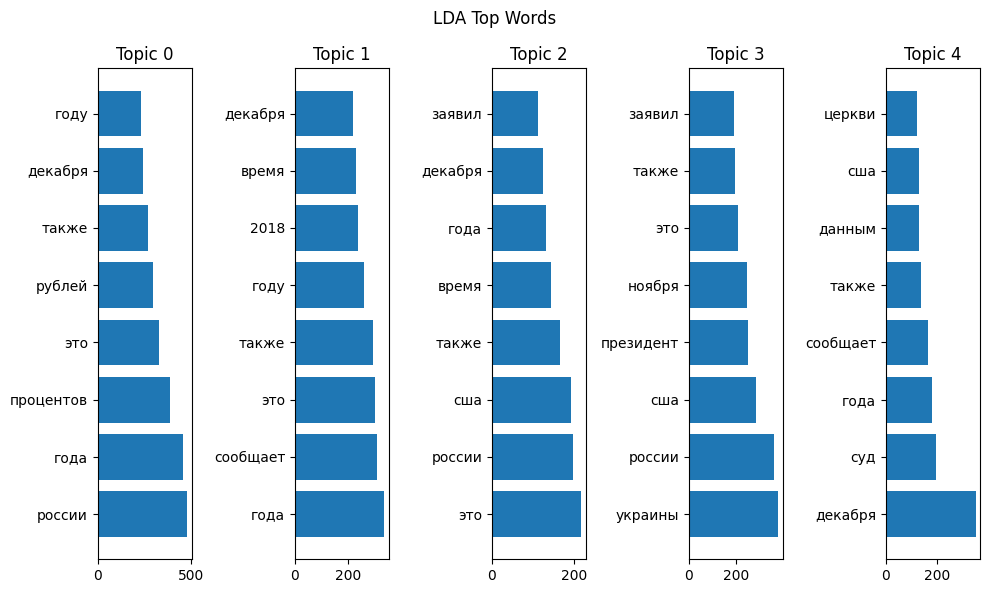

In [49]:
# LDA
lda_model = train_lda(docs, n_topics=5)
plot_top_words(lda_model, vectorizer_count.get_feature_names_out(), title='LDA Top Words')


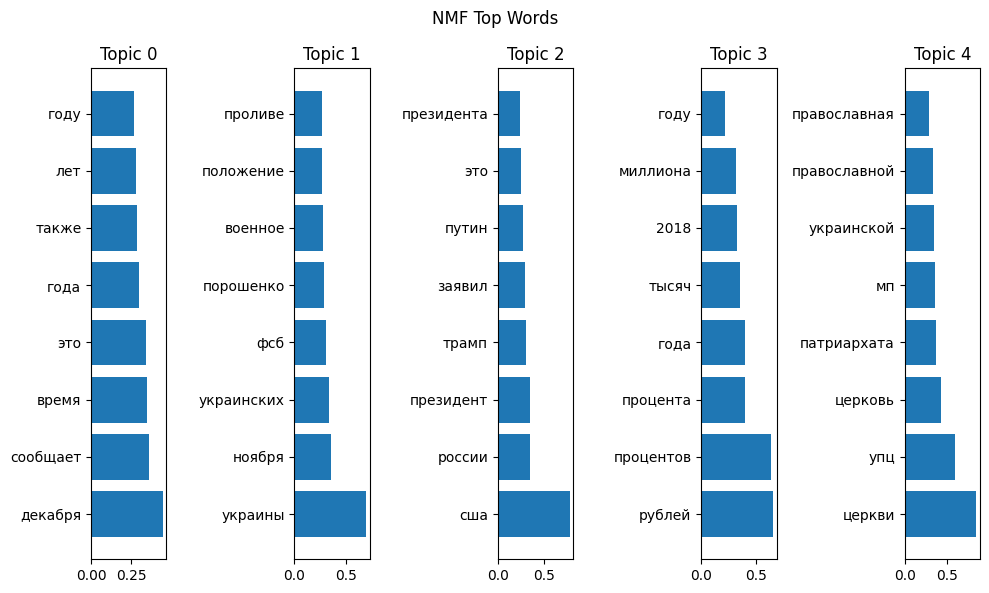

In [50]:
# NMF
nmf_model = train_nmf(docs, n_topics=5)
plot_top_words(nmf_model, vectorizer_tfidf.get_feature_names_out(), title='NMF Top Words')


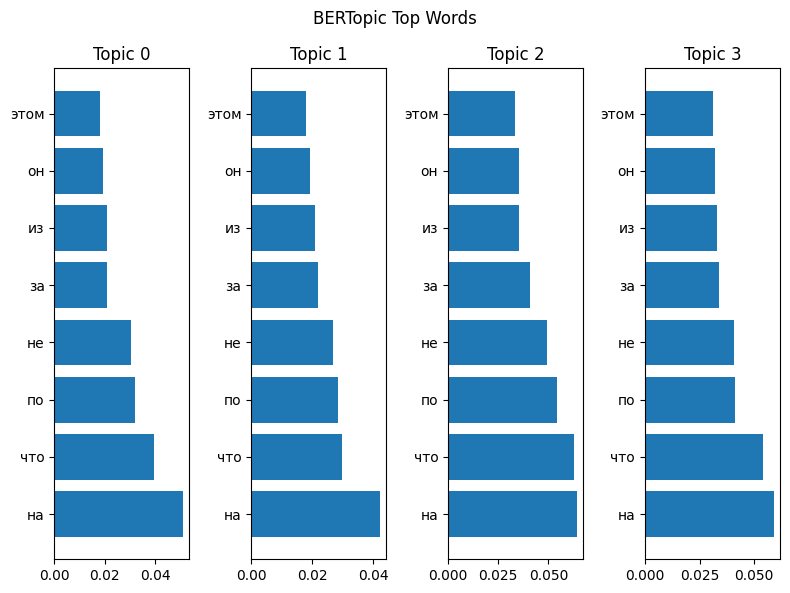

In [69]:
    bert_model = train_bertopic(docs, n_topics=5)
    info = bert_model.get_topic_info()
    topic_ids = [t for t in info.Topic.tolist() if t != -1][:5]
    bert_components = []
    bert_features = None
    for t_id in topic_ids:
        tw = bert_model.get_topic(t_id)
        if not tw:
            continue
        words, weights = zip(*tw[:8])  # top-8 terms
        if bert_features is None:
            bert_features = list(words)
        bert_components.append(np.array(weights))
    class BERTWrapper:
        n_components = len(bert_components)
        components_ = np.array(bert_components)
    plot_top_words(BERTWrapper(), bert_features, title='BERTopic Top Words')

In [97]:
# Fastopic
fast_model = train_fastopic(docs, n_topics=5)
fast_model.plot_topics()

AssertionError: 